# **Definitive EDA Target (Parts 0–3)**

**Goal**: verify data integrity, understand Kp (target), characterize drivers, and identify physically plausible relationships — **without modeling**.

---

- timestamp_utc — UTC timestamp marking the end of each 3‑hour window (t−3h, t].
- kp — GFZ Kp index for the same 3‑hour interval (target label proxy).
- bz_gsm_3h_min — Minimum Bz (GSM) in the 3‑hour window; captures strongest southward turning.
- by_gsm_3h_mean — Mean By (GSM) over the 3‑hour window; field orientation context.
- b_scalar_3h_mean — Mean magnetic field magnitude |B| over the 3‑hour window.
- sw_speed_3h_mean — Mean solar wind speed (km/s) over the 3‑hour window.
- sw_density_3h_mean — Mean solar wind proton density (cm^-3) over the 3‑hour window.
- sw_temperature_3h_mean — Mean solar wind plasma temperature (K) over the 3‑hour window (optional driver; often missing early in record).

## **Part 0 — Load & Sanity Checks**

Shape: (181385, 8)
Date range: 1963-11-28 00:00:00+00:00 → 2025-12-25 00:00:00+00:00

Dtypes:
 timestamp_utc             datetime64[ns, UTC]
kp                                    float64
bz_gsm_3h_min                         float64
by_gsm_3h_mean                        float64
b_scalar_3h_mean                      float64
sw_speed_3h_mean                      float64
sw_density_3h_mean                    float64
sw_temperature_3h_mean                float64
dtype: object


,percent_missing
sw_temperature_3h_mean,27.898669
sw_density_3h_mean,24.777132
sw_speed_3h_mean,21.818783
by_gsm_3h_mean,20.964799
bz_gsm_3h_min,20.964799
b_scalar_3h_mean,20.959837
timestamp_utc,0.000000
kp,0.000000


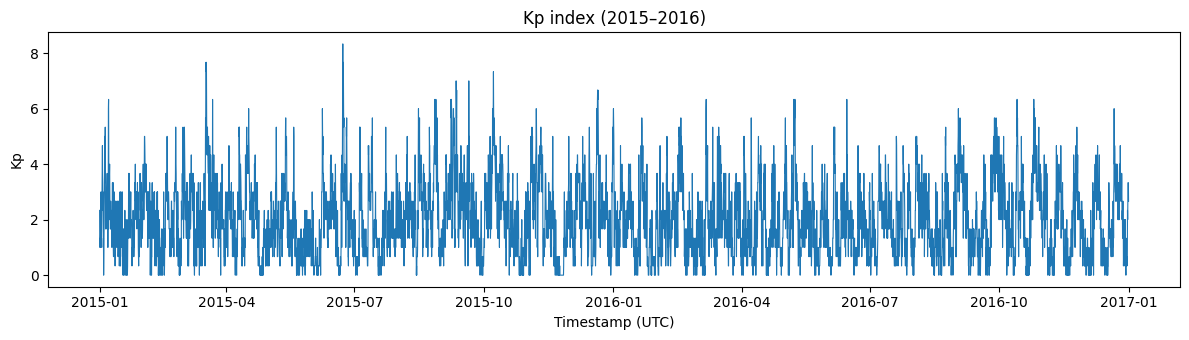

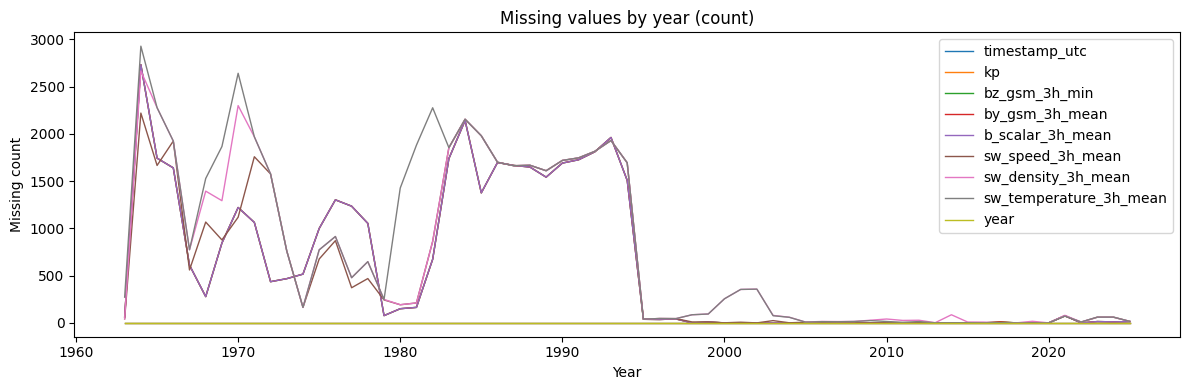

,first_missing,last_missing,missing_count
sw_temperature_3h_mean,1963-11-28 00:00:00+00:00,2025-11-27 21:00:00+00:00,50604
sw_density_3h_mean,1963-11-28 00:00:00+00:00,2025-11-27 21:00:00+00:00,44942
sw_speed_3h_mean,1963-11-28 00:00:00+00:00,2025-11-27 21:00:00+00:00,39576
bz_gsm_3h_min,1963-11-28 00:00:00+00:00,2025-11-27 21:00:00+00:00,38027
by_gsm_3h_mean,1963-11-28 00:00:00+00:00,2025-11-27 21:00:00+00:00,38027
b_scalar_3h_mean,1963-11-28 00:00:00+00:00,2025-11-27 21:00:00+00:00,38018


,timestamp_utc,kp,bz_gsm_3h_min,by_gsm_3h_mean,b_scalar_3h_mean,sw_speed_3h_mean,sw_density_3h_mean,sw_temperature_3h_mean,year,year_bin
year_bin,,,,,,,,,,
1960-1966,0.0,0.0,68.340708,68.340708,68.340708,64.745575,76.438053,81.869469,0.0,0.0
1967-1973,0.0,0.0,24.061400,24.061400,24.061400,37.729761,49.208056,54.336136,0.0,0.0
1974-1980,0.0,0.0,26.065702,26.065702,26.065702,14.597184,16.704145,22.741494,0.0,0.0
1981-1987,0.0,0.0,46.244131,46.244131,46.244131,50.982981,50.987872,66.065141,0.0,0.0
1988-1994,0.0,0.0,58.114978,58.114978,58.114978,59.552210,59.552210,59.552210,0.0,0.0
1995-2001,0.0,0.0,0.611068,0.611068,0.611068,0.772390,4.497458,4.497458,0.0,0.0
2002-2008,0.0,0.0,0.000000,0.000000,0.000000,0.156433,2.683809,2.639812,0.0,0.0
2009-2015,0.0,0.0,0.000000,0.000000,0.000000,0.014671,1.075900,0.308099,0.0,0.0
2016-2022,0.0,0.0,0.425303,0.425303,0.381306,0.405749,0.567071,0.410637,0.0,0.0


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Part 0 — Load & Sanity Checks + Missingness
df = pd.read_parquet("../Data/processed/master_3h.parquet")

# Global info
print("Shape:", df.shape)
print("Date range:", df["timestamp_utc"].min(), "→", df["timestamp_utc"].max())
print("\nDtypes:\n", df.dtypes)

# Time integrity (hard checks)
ts = df["timestamp_utc"]
assert ts.is_monotonic_increasing, "timestamp_utc is not strictly increasing"
assert ts.is_unique, "timestamp_utc has duplicates"
deltas = ts.diff().dropna()
assert (deltas == pd.Timedelta(hours=3)).all(), "timestamp_utc spacing is not 3 hours"

# Missingness table
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame("percent_missing"))

# Quick visual sanity (1–2 year slice)
slice_df = df[(df["timestamp_utc"] >= "2015-01-01") & (df["timestamp_utc"] < "2017-01-01")]
plt.figure(figsize=(12, 3.5))
plt.plot(slice_df["timestamp_utc"], slice_df["kp"], linewidth=0.8)
plt.title("Kp index (2015–2016)")
plt.xlabel("Timestamp (UTC)")
plt.ylabel("Kp")
plt.tight_layout()
plt.show()

# Missing counts by year
df["year"] = df["timestamp_utc"].dt.year
missing_by_year = df.isna().groupby(df["year"]).sum()

plt.figure(figsize=(12, 4))
missing_by_year.plot(ax=plt.gca(), linewidth=1)
plt.title("Missing values by year (count)")
plt.xlabel("Year")
plt.ylabel("Missing count")
plt.tight_layout()
plt.show()

# First/last missing date per column
missing_dates = {}
for col in df.columns:
  if col in {"timestamp_utc", "year"}:
      continue
  miss_idx = df.loc[df[col].isna(), "timestamp_utc"]
  if not miss_idx.empty:
      missing_dates[col] = {
          "first_missing": miss_idx.min(),
          "last_missing": miss_idx.max(),
          "missing_count": miss_idx.size,
      }


missing_dates_df = pd.DataFrame(missing_dates).T.sort_values("missing_count", ascending=False)
display(missing_dates_df)

# Missing count by 7-year bins
bin_start = (df["year"] // 7) * 7
df["year_bin"] = bin_start.astype(str) + "-" + (bin_start + 6).astype(str)

missing_by_bin_pct = df.isna().groupby(df["year_bin"]).mean() * 100
display(missing_by_bin_pct)



Missingness is concentrated in the early record (pre‑1996) across all OMNI drivers. From ~1996 onward the data are mostly complete, with only sparse gaps. OMNI Kp is nearly complete, but plasma/IMF variables have substantial
  early‑era missingness.

This missingness should be fine over model like forest, XBoost but might need some thought for other models. restraining 1996-2025 might also be enough as the database is quite extensive.


## **Part 1 — Target (Kp) Analysis**

### Purpose

Understand the **statistical and temporal structure** of the label proxy (Kp).


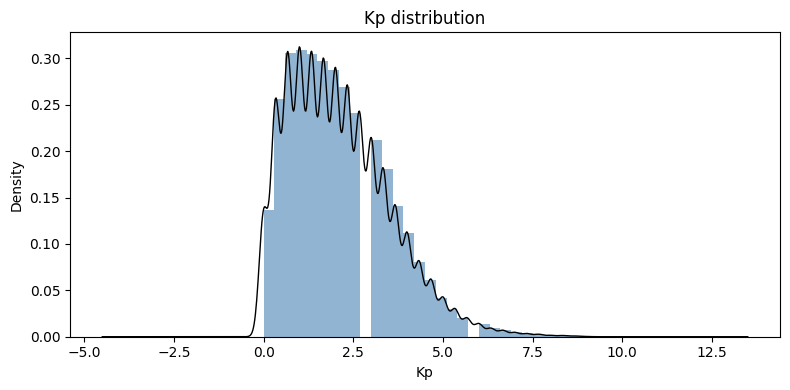

,kp_quantile
0.01,0.000
0.05,0.333
0.50,2.000
0.95,4.667
0.99,6.000


/tmp/ipykernel_59603/84583348.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  kp_monthly = kp["kp"].resample("M").mean()


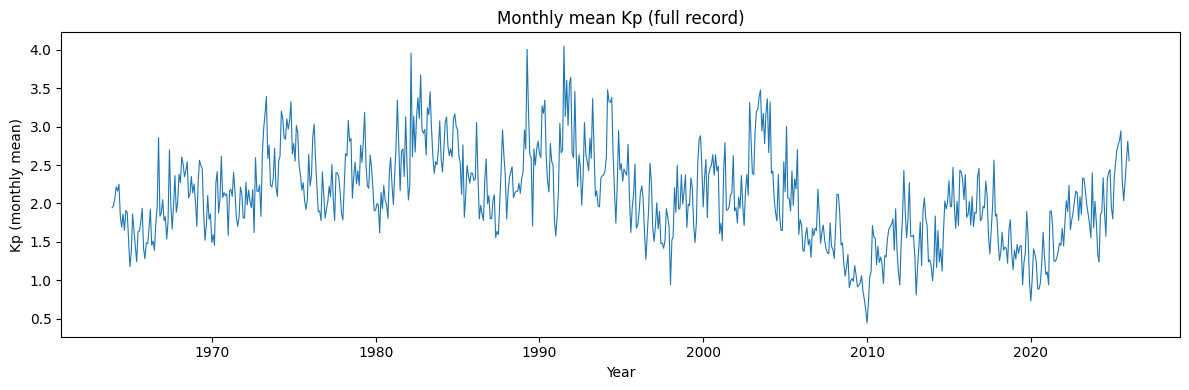

/tmp/ipykernel_59603/84583348.py:36: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_counts = kp_events.resample("Y").sum()


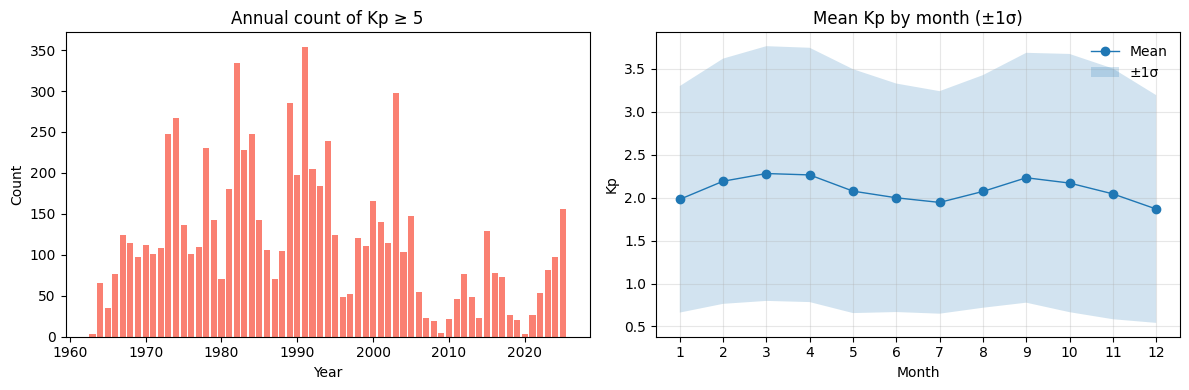

In [45]:


# Part 1 — Target (Kp) Analysis
kp = df[["timestamp_utc", "kp"]].dropna().copy()
kp = kp.sort_values("timestamp_utc")
kp = kp.set_index("timestamp_utc")

# 1) Distribution (hist + KDE)
plt.figure(figsize=(8, 4))
kp["kp"].plot(kind="hist", bins=30, density=True, alpha=0.6, color="steelblue")
kp["kp"].plot(kind="kde", color="black", linewidth=1)
plt.title("Kp distribution")
plt.xlabel("Kp")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Optional quantiles
quantiles = kp["kp"].quantile([0.01, 0.05, 0.5, 0.95, 0.99])
display(quantiles.to_frame("kp_quantile"))

# 2) Long-term behavior (monthly mean over full record)
kp_monthly = kp["kp"].resample("M").mean()
plt.figure(figsize=(12, 4))
plt.plot(kp_monthly.index, kp_monthly.values, linewidth=0.8)
plt.title("Monthly mean Kp (full record)")
plt.xlabel("Year")
plt.ylabel("Kp (monthly mean)")
plt.tight_layout()
plt.show()

# 3) Event structure + seasonality (single 2-panel figure)
kp_events = (kp["kp"] >= 5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Annual storm counts (Kp >= 5)
annual_counts = kp_events.resample("Y").sum()
axes[0].bar(annual_counts.index.year, annual_counts.values, width=0.8, color="salmon")
axes[0].set_title("Annual count of Kp ≥ 5")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

import numpy as np

# Seasonality: mean Kp by month (with ±1 std band)
g = kp["kp"].groupby(kp.index.month)

monthly_mean = g.mean()
monthly_std  = g.std()

months = np.arange(1, 13)

axes[1].plot(months, monthly_mean.values, marker="o", linewidth=1, label="Mean")
axes[1].fill_between(
    months,
    (monthly_mean - monthly_std).values,
    (monthly_mean + monthly_std).values,
    alpha=0.2,
    label="±1σ"
)

axes[1].set_title("Mean Kp by month (±1σ)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Kp")
axes[1].set_xticks(months)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()





### Target (Kp) Analysis: Key Observations**

* **Distribution**: Kp is strongly right-skewed, with most values in the quiet–moderate range (median ≈ 2) and a long upper tail; geomagnetic storms (Kp ≥ 5) lie in the top ~5% of observations, confirming a rare-event, tail-driven regime.

* **Temporal variability**: Monthly mean Kp exhibits pronounced multi-decadal modulation consistent with solar-cycle variability, with no monotonic long-term trend, indicating approximate (not strict) stationarity and motivating time-local validation.

* **Event structure**: Annual counts of Kp ≥ 5 vary strongly from year to year and cluster during active solar periods, showing that storm occurrence is bursty and regime-dependent rather than Poisson-like. With recently lesser activity than before 2007 but in a growing momentum occurring since 2023. Good years to seesight Northen lights right now :D

* **Seasonality**: Mean Kp exhibits a clear semiannual modulation, with enhanced activity near the equinoxes and reduced levels in winter. While the seasonal cycle shifts the typical activity level, substantial variability persists throughout the year, justifying the use of seasonal encoding as contextual information rather than a standalone predictor.

* **Implications**: These properties support an event-based, imbalanced classification framing with explicit temporal handling, while deliberately making no claims about predictability, driver attribution, or model structure at this stage.

The Kp index exhibits a strongly right-skewed distribution, with quiet to moderate conditions dominating and geomagnetic storms occurring as rare, high-magnitude events. This skewness is physically expected, reflecting the intermittent and burst-driven nature of solar-wind–magnetosphere coupling rather than measurement artifacts.

From a prediction standpoint, this distributional structure makes direct regression on Kp ill-posed.

This motivates framing the task as an event-based, probabilistic prediction problem. Rather than estimating exact Kp values, the objective is to predict the likelihood of storm-level activity occurring within a future time window. In this formulation, class imbalance is intrinsic to the problem and must be handled explicitly through appropriate metrics, calibration, and baselines.

Overall, the right-skewed nature of Kp does not limit predictability itself, but it fundamentally shapes how predictability should be defined, evaluated, and interpreted: predictive skill is conditional on rare events and cannot be uniform across all activity levels.



## **Part 2 — Driver Analysis (OMNI Variables)**

### Purpose

Verify **physical plausibility, ranges, and data quality** of solar-wind drivers.


,mean,median,std,min,max
kp,2.092242,2.000000,1.411633,0.000000,9.000000e+00
bz_gsm_3h_min,-1.267560,-1.100000,3.009479,-57.800000,2.750000e+01
by_gsm_3h_mean,-0.041696,-0.100000,3.750224,-34.350000,3.490000e+01
b_scalar_3h_mean,6.178237,5.500000,3.110871,0.666667,6.090000e+01
sw_speed_3h_mean,433.886741,410.666667,101.550053,163.000000,1.177667e+03
sw_density_3h_mean,6.657128,5.166667,5.216563,0.000000,9.946667e+01
sw_temperature_3h_mean,102611.422823,74712.333333,94449.605526,3385.000000,4.425854e+06


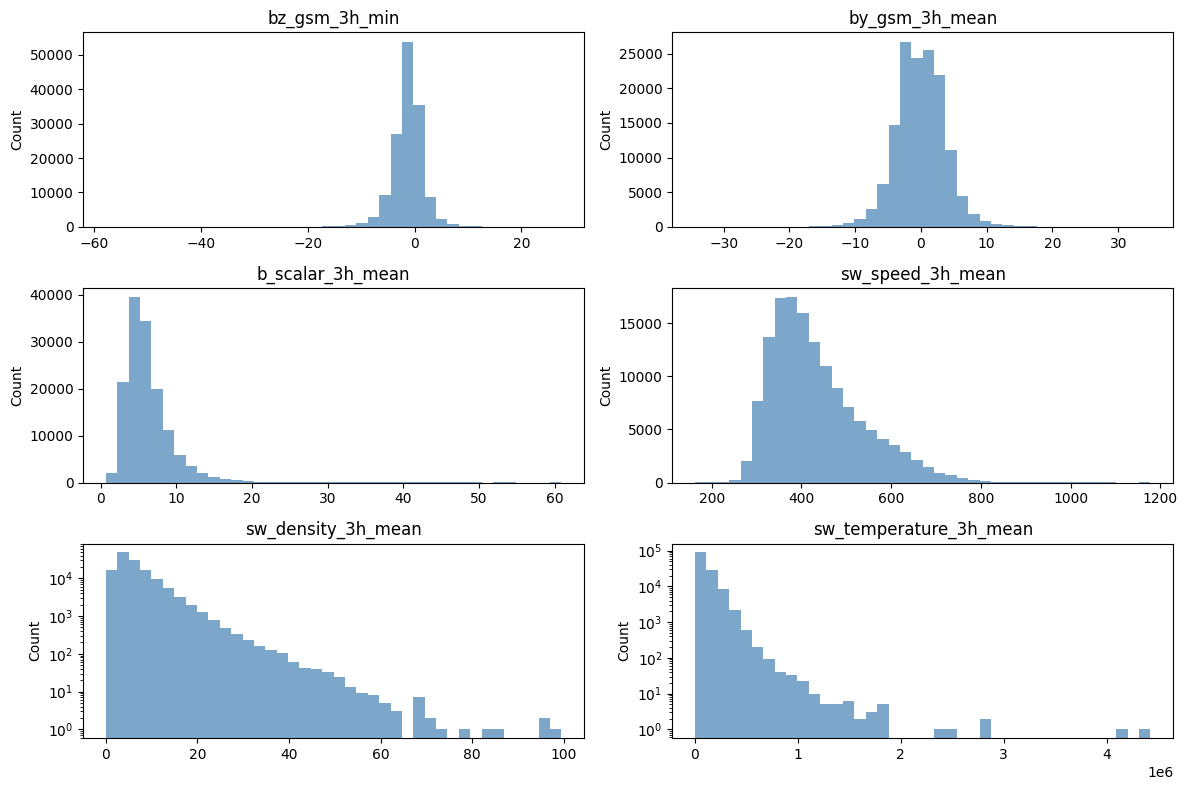

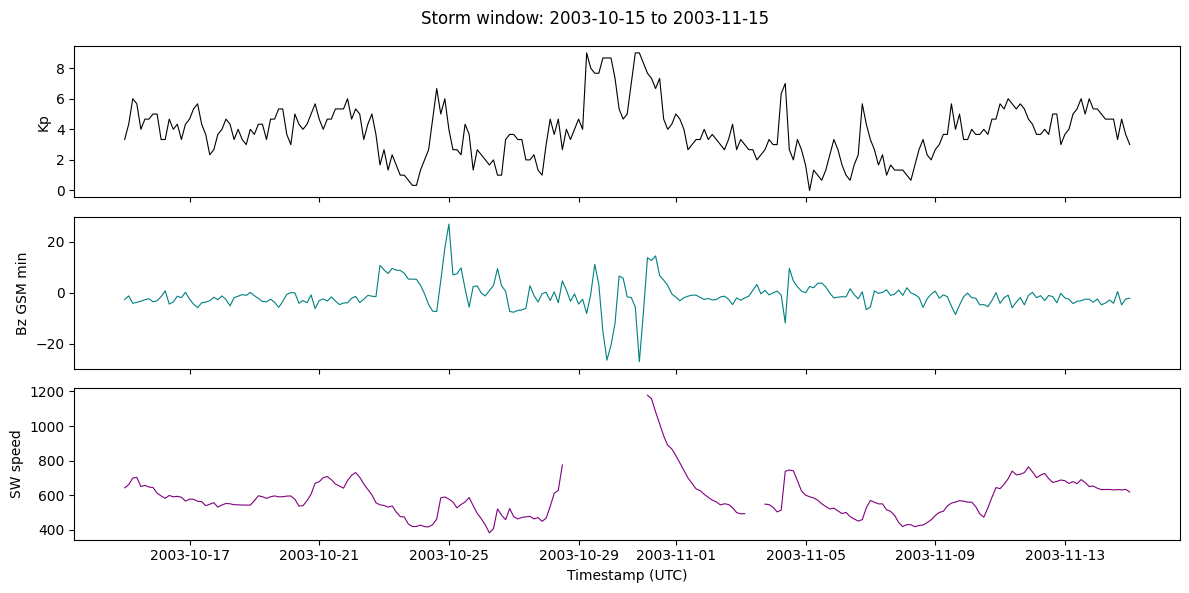

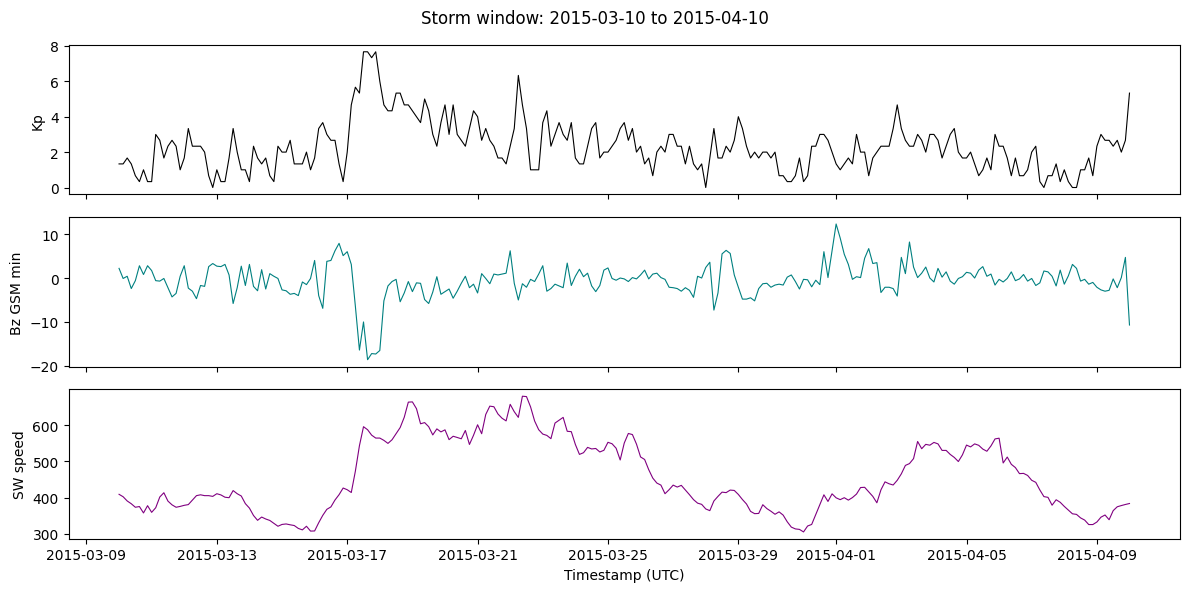

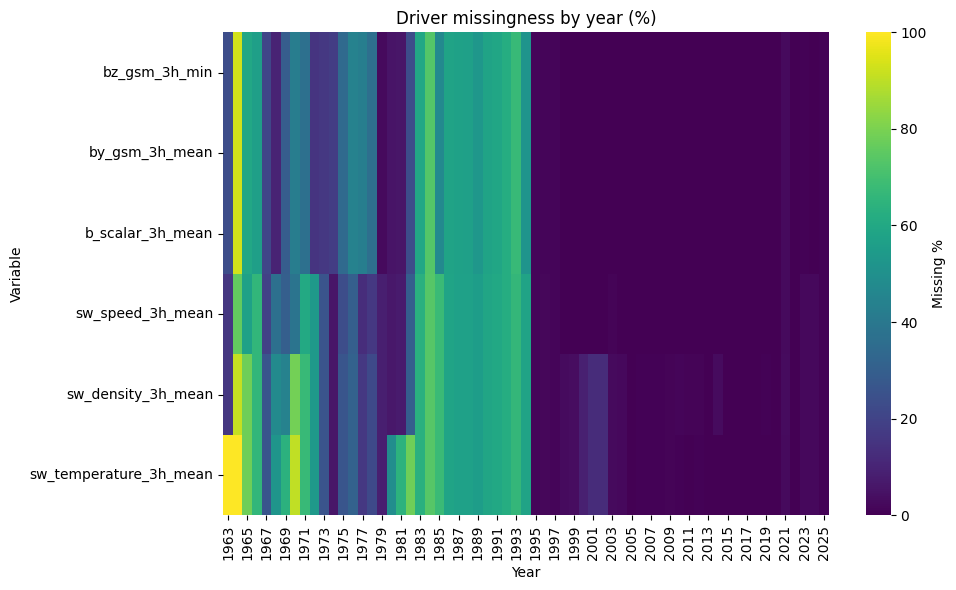

In [46]:

# Part 2 — Driver Analysis (OMNI Variables)
drivers = [
  "bz_gsm_3h_min",
  "by_gsm_3h_mean",
  "b_scalar_3h_mean",
  "sw_speed_3h_mean",
  "sw_density_3h_mean",
  "sw_temperature_3h_mean",
]
stats_cols = ["kp"] + drivers

# 1) Summary statistics
stats = df[stats_cols].describe().T[["mean", "50%", "std", "min", "max"]]
stats = stats.rename(columns={"50%": "median"})
display(stats)

# 2) Distributions (histograms)
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, drivers):
  series = df[col].dropna()
  ax.hist(series, bins=40, color="steelblue", alpha=0.7)
  ax.set_title(col)
  if col in {"sw_density_3h_mean", "sw_temperature_3h_mean"}:
      ax.set_yscale("log")
  ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# 3) Storm snapshots (2–4 week windows)
def plot_window(start, end):
  window = df[(df["timestamp_utc"] >= start) & (df["timestamp_utc"] <= end)]
  if window.empty:
      print(f"No data in window {start} to {end}")
      return

  fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

  axes[0].plot(window["timestamp_utc"], window["kp"], color="black", linewidth=0.8)
  axes[0].set_ylabel("Kp")

  axes[1].plot(window["timestamp_utc"], window["bz_gsm_3h_min"], color="teal", linewidth=0.8)
  axes[1].set_ylabel("Bz GSM min")

  axes[2].plot(window["timestamp_utc"], window["sw_speed_3h_mean"], color="purple", linewidth=0.8)
  axes[2].set_ylabel("SW speed")

  axes[2].set_xlabel("Timestamp (UTC)")
  plt.suptitle(f"Storm window: {start} to {end}")
  plt.tight_layout()
  plt.show()

plot_window("2003-10-15", "2003-11-15")
plot_window("2015-03-10", "2015-04-10")

# 4) Missingness over time (heatmap if >5% missing)
missing_pct = df[drivers].isna().mean() * 100
if (missing_pct > 5).any():
  df["year"] = df["timestamp_utc"].dt.year
  missing_by_year = df[drivers].isna().groupby(df["year"]).mean() * 100

  plt.figure(figsize=(10, 6))
  sns.heatmap(missing_by_year.T, cmap="viridis", cbar_kws={"label": "Missing %"})
  plt.title("Driver missingness by year (%)")
  plt.xlabel("Year")
  plt.ylabel("Variable")
  plt.tight_layout()
  plt.show()


### **Driver distributions (physical plausibility)**

* **IMF (Bz, By)**: centered near zero with heavy tails; strong southward Bz events are rare but extreme.
* **Magnetic field magnitude**: right-skewed, with a narrow typical range and a long disturbed tail.
* **Solar wind speed**: dominated by slow wind, with rare but sustained high-speed streams.
* **Density & temperature**: highly right-skewed with orders-of-magnitude variability, requiring log-scaling.

**Implication**: Driver distributions are non-Gaussian; extreme geomagnetic conditions arise from tail events, and feature scaling will be necessary (raw magnitudes differ by orders of magnitude).

---

### **Storm snapshots (qualitative coupling)**

* Elevated Kp coincides with **persistent southward Bz** and **enhanced solar wind speed**.
* Brief Bz spikes alone do not trigger strong activity.
* Storms emerge from **sustained conditions**, not instantaneous extremes.

**Implication**: Consistent with known coupling physics; motivates lagged, rolling, and persistence-based features (without claiming causality).

---

### **Missingness over time (data quality)**

* Early records (pre-1995) contain substantial gaps, especially in density and temperature.
* Recent decades show near-complete coverage across drivers.
* Missingness is structured in time and consistent across variables.

**Implication**: Modeling must be time-aware and robust to early-period sparsity; handling strategy is deferred.

---

### **What can be concluded **

* Solar wind drivers are heavy-tailed and regime-dependent.
* Extreme geomagnetic activity is associated with persistent driver excursions.
* Data quality is heterogeneous but physically coherent.
* These properties justify lagged and rolling features later.

**Not concluded**: driver ranking, standalone predictiveness, or optimal lag selection.





## **Part 3 — Correlation & Relationships**

### Purpose

Identify **dependencies, collinearity, and plausible lag structure** — not feature importance.

### Analyses

1. **Correlation overview**

* Pearson correlation matrix (numeric columns only)
* Heatmap, lower triangle only

2. **Instantaneous relationships**

* Scatter or hexbin:

 * Kp vs Bz
 * Kp vs SW speed
 * Kp vs density (optional)

3. **Lagged correlations (key drivers only)**

* Corr(driver(t), Kp(t+lag))
* Lag range: 0 → 24 h
* Drivers:

 * Bz min
 * SW speed
 * Density



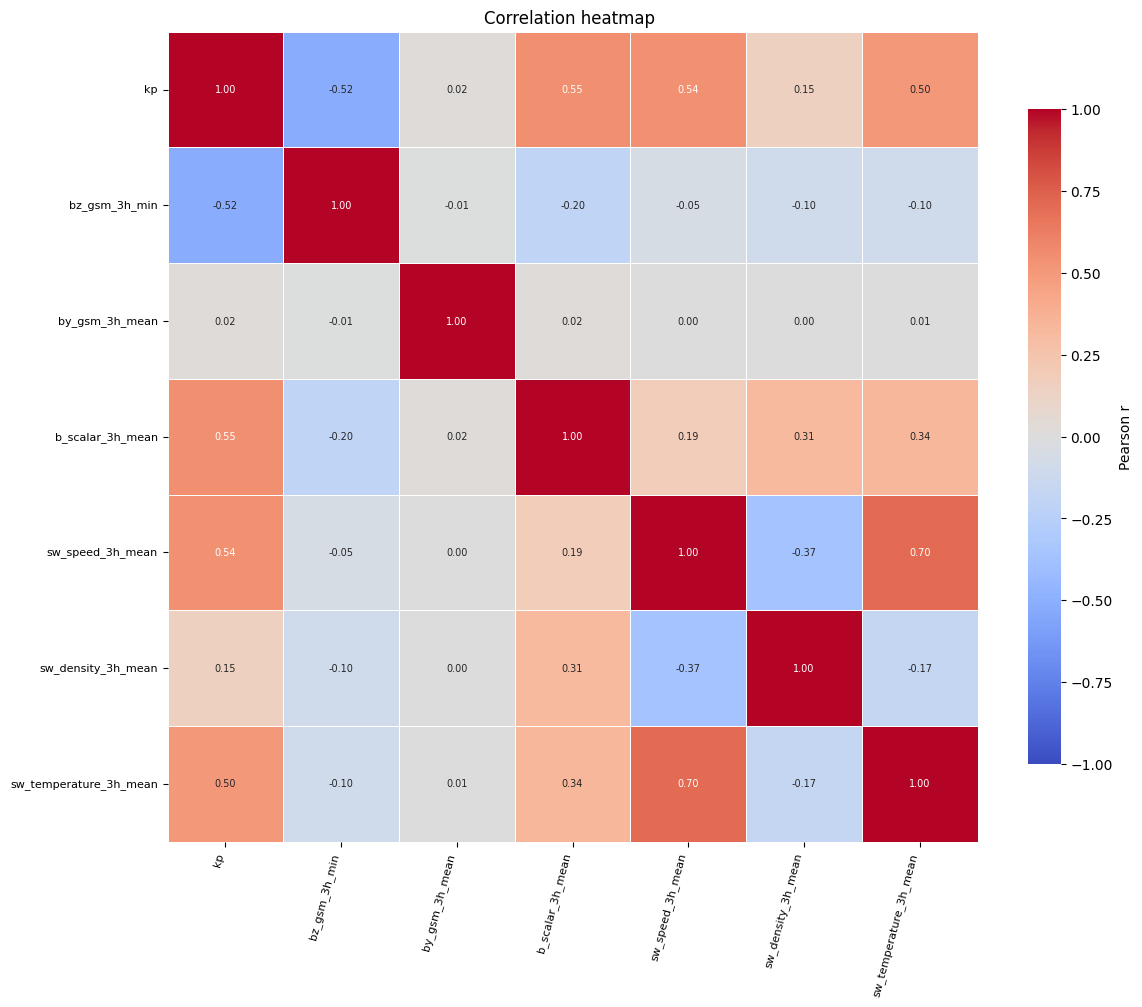

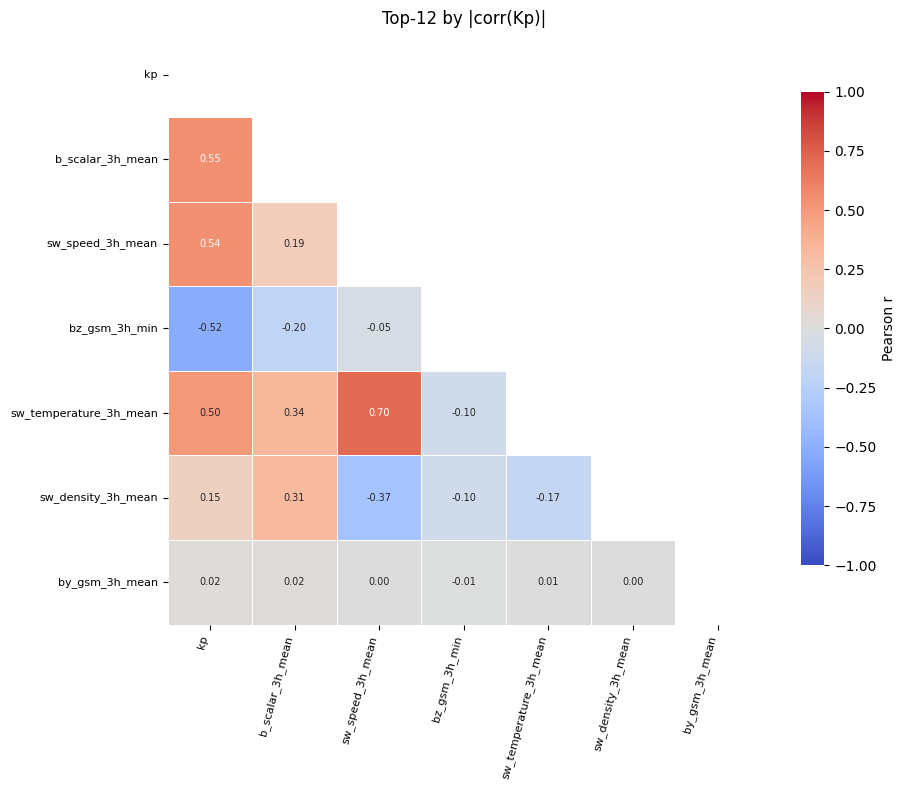

In [48]:
# Part 3 — Correlation & Relationships

# 1) Correlation overview (numeric only, lower triangle)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrices
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["year", "year_bin"], errors="ignore")
corr = numeric_df.corr()

# 1) Full correlation heatmap (lower triangle)
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(
  corr,
  cmap="coolwarm",
  center=0,
  vmin=-1, vmax=1,
  square=True,
  linewidths=0.6,
  annot=True,
  fmt=".2f",
  annot_kws={"size": 7},
  cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Correlation heatmap ")
ax.tick_params(axis="x", rotation=75, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
for lbl in ax.get_xticklabels():
  lbl.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

# 2) Top-K by |corr(Kp)|
target = "kp"
k = 12  # adjust if you want
rank = corr[target].abs().sort_values(ascending=False)
cols = [target] + [c for c in rank.index if c != target][: k - 1]
corr_k = corr.loc[cols, cols]

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_k, dtype=bool))
ax = sns.heatmap(
  corr_k,
  mask=mask,
  cmap="coolwarm",
  center=0,
  vmin=-1, vmax=1,
  square=True,
  linewidths=0.6,
  annot=True,
  fmt=".2f",
  annot_kws={"size": 7},
  cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title(f"Top-{k} by |corr(Kp)|")
ax.tick_params(axis="x", rotation=75, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
for label in ax.get_xticklabels():
  label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()



## Interpretation of the instantaneous correlation matrix

This matrix reports **instantaneous (same 3-hour step) Pearson correlations** between Kp and selected solar-wind / IMF drivers, as well as inter-driver correlations. It captures **linear co-variation only**, without temporal context.

---

### 1. Correlation with Kp (target proxy)

* **Solar wind speed (`sw_speed_3h_mean`)**
  Shows a moderate positive correlation with Kp (≈ 0.54), indicating that elevated geomagnetic activity tends to occur during faster solar-wind conditions.

* **Magnetic field magnitude (`b_scalar_3h_mean`)**
  Exhibits a similar positive correlation (≈ 0.55), consistent with enhanced magnetic energy input during disturbed solar-wind regimes.

* **Southward IMF (`bz_gsm_3h_min`)**
  Is moderately negatively correlated with Kp (≈ −0.52), reflecting the well-known role of sustained southward IMF in enabling magnetospheric coupling.

* **Solar wind temperature (`sw_temperature_3h_mean`)**
  Shows a moderate positive correlation (≈ 0.50), likely reflecting its association with high-speed streams rather than a direct coupling mechanism.

* **Density and IMF By**
  Display weak instantaneous correlations with Kp, suggesting their influence is conditional, indirect, or expressed through temporal accumulation rather than same-step linear dependence.

---

### 2. Inter-driver relationships (collinearity)

* **Speed–temperature coupling** is strong (r ≈ 0.70), indicating shared solar-wind regimes.
* **Speed–magnetic field magnitude** shows mild correlation, consistent with energetic streams carrying stronger fields.
* **Density** is weakly or negatively correlated with speed and temperature, reflecting the typical fast-wind / low-density vs slow-wind / high-density structure.

These correlations are **physically expected** and indicate that drivers are **not independent**, which is important for downstream modeling.

---

### 3. What this matrix does and does not imply

**What it shows**

* Linear, instantaneous co-variation consistent with known solar-wind–magnetosphere coupling.
* No single driver dominates Kp at the same time step.
* Multiple drivers contribute in a correlated, regime-dependent manner.

**What it does not show**

* Causality or directionality.
* Optimal time lags or accumulation effects.
* Predictive power at future horizons.

---

Instantaneous correlations reveal physically consistent but moderate linear associations between Kp and key solar-wind drivers, with substantial inter-driver collinearity and no dominant single predictor. This confirms that geomagnetic activity cannot be explained by same-step linear relationships alone and motivates the use of lagged, multivariate, and horizon-aware analysis.




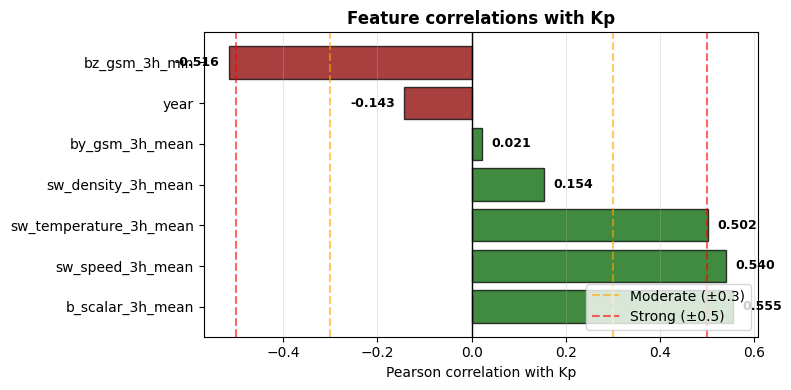


Correlation strength distribution (with Kp):


kp
Very weak\n(0–0.1)        1
Weak\n(0.1–0.3)           2
Moderate\n(0.3–0.5)       0
Strong\n(0.5–0.7)         4
Very strong\n(0.7–1.0)    0
Name: count, dtype: int64

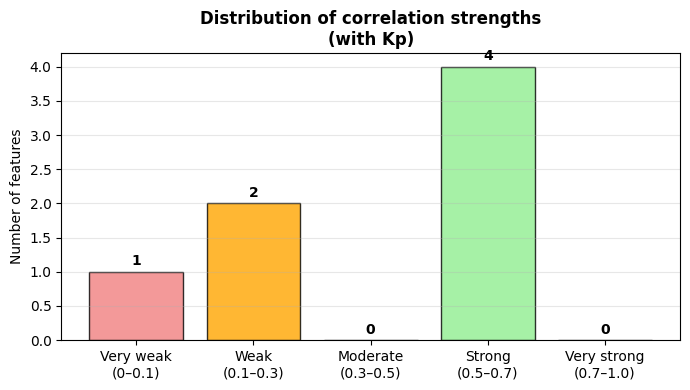

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Correlations with Kp
numeric_cols = df.select_dtypes(include=["number"]).columns
corr = df[numeric_cols].corr(numeric_only=True)

target = "kp"
target_corr = (
  corr[target]
  .drop(target)
  .dropna()
  .sort_values(ascending=False)
)

# --- Bar chart ---
plt.figure(figsize=(8, max(4, 0.35 * len(target_corr))))
colors = ["darkgreen" if v > 0 else "darkred" for v in target_corr.values]

bars = plt.barh(
  target_corr.index,
  target_corr.values,
  color=colors,
  edgecolor="black",
  alpha=0.75,
)

plt.axvline(0, color="black", linewidth=1)
plt.axvline(0.3, color="orange", linestyle="--", alpha=0.6, label="Moderate (±0.3)")
plt.axvline(-0.3, color="orange", linestyle="--", alpha=0.6)
plt.axvline(0.5, color="red", linestyle="--", alpha=0.6, label="Strong (±0.5)")
plt.axvline(-0.5, color="red", linestyle="--", alpha=0.6)

for bar, val in zip(bars, target_corr.values):
  plt.text(
      val + (0.02 if val > 0 else -0.02),
      bar.get_y() + bar.get_height() / 2,
      f"{val:.3f}",
      va="center",
      ha="left" if val > 0 else "right",
      fontsize=9,
      fontweight="bold",
  )

plt.xlabel("Pearson correlation with Kp")
plt.title("Feature correlations with Kp", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Correlation strength distribution ---
abs_corr = target_corr.abs()
bins = [0, 0.1, 0.3, 0.5, 0.7, 1.0]
labels = [
  "Very weak\n(0–0.1)",
  "Weak\n(0.1–0.3)",
  "Moderate\n(0.3–0.5)",
  "Strong\n(0.5–0.7)",
  "Very strong\n(0.7–1.0)",
]

strength_dist = pd.cut(abs_corr, bins=bins, labels=labels).value_counts().sort_index()
print("\nCorrelation strength distribution (with Kp):")
display(strength_dist)

plt.figure(figsize=(7, 4))
colors = ["lightcoral", "orange", "gold", "lightgreen", "darkgreen"]
bars = plt.bar(
  strength_dist.index,
  strength_dist.values,
  color=colors,
  edgecolor="black",
  alpha=0.8,
)

for bar, val in zip(bars, strength_dist.values):
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() + 0.05,
      str(val),
      ha="center",
      va="bottom",
      fontweight="bold",
  )

plt.ylabel("Number of features")
plt.title("Distribution of correlation strengths\n(with Kp)", fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

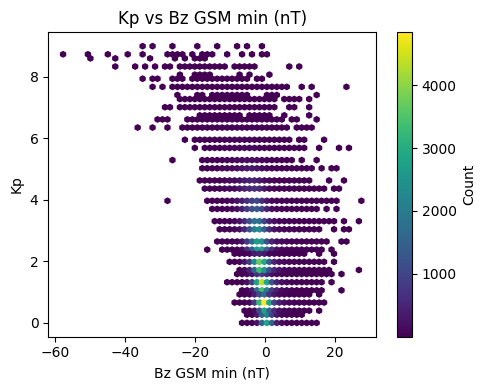

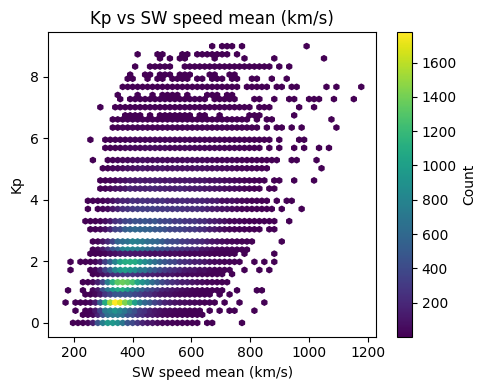

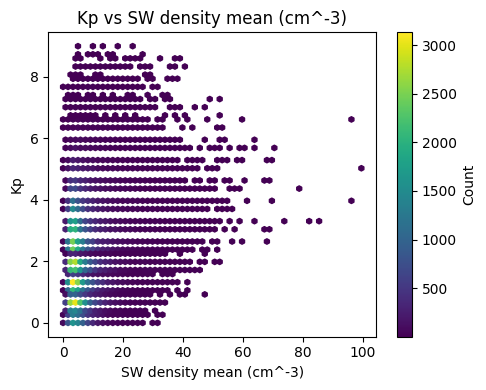

In [52]:

# Hexbin with colorbars
def hexplot(x, y, xlabel, ylabel, gridsize=60):
  plt.figure(figsize=(5, 4))
  hb = plt.hexbin(x, y, gridsize=gridsize, cmap="viridis", mincnt=1)
  plt.colorbar(hb, label="Count")
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(f"{ylabel} vs {xlabel}")
  plt.tight_layout()
  plt.show()


hexplot(df["bz_gsm_3h_min"], df["kp"], "Bz GSM min (nT)", "Kp")
hexplot(df["sw_speed_3h_mean"], df["kp"], "SW speed mean (km/s)", "Kp")
hexplot(df["sw_density_3h_mean"], df["kp"], "SW density mean (cm^-3)", "Kp")



## How to read these hexbin plots (reminder)

* Each hexagon aggregates many 3-hour samples.
* Color = **data density** (where the system spends most of its time).
* Vertical spread at fixed x = **variability / non-determinism**.
* Slanted or wedge-shaped envelopes = **conditional relationships**, not linear laws.

These plots answer:

> *“Under what driver conditions do high Kp values tend to occur?”*

---

## 1) **Kp vs Bz GSM min**

### What you see

* High Kp values occur **almost exclusively when Bz is negative**.
* For **Bz > 0**, Kp is nearly always low to moderate.
* Even for strongly negative Bz, Kp spans a wide range.

### What this means

* **Southward IMF is a necessary but not sufficient condition** for storms.
* Negative Bz enables coupling, but does not guarantee high Kp.
* The triangular shape reflects **conditional triggering**:

  * positive Bz → activity suppressed
  * negative Bz → activity possible, but variable

### Key takeaway

> Bz acts as a **gatekeeper variable**, not a predictor on its own.

---

## 2) **Kp vs solar wind speed**

### What you see

* High Kp becomes **more frequent** as speed increases.
* At low speeds, Kp is almost always small.
* At high speeds, Kp ranges from low to very high.

### What this means

* Solar wind speed **modulates the intensity** of activity once coupling is enabled.
* Speed alone does not trigger storms, but it **amplifies outcomes**.
* The diagonal wedge shows a **probabilistic influence**, not a threshold.

### Key takeaway

> Speed is a **conditioning / amplifying variable**, not a switch.

---

## 3) **Kp vs solar wind density**

### What you see

* High density mostly coincides with **low to moderate Kp**.
* High Kp events occur across a wide density range.
* No clear monotonic or threshold structure.

### What this means

* Density has **weak instantaneous influence** on Kp.
* Its role is likely indirect (pressure, compression, context).
* Any effect probably manifests through **temporal accumulation**, not same-step correlation.

### Key takeaway

> Density is a **secondary or contextual driver**, not a primary one.

---

## Cross-plot synthesis

Across all three plots:

* No driver shows a **deterministic relationship** with Kp.
* High Kp arises from **specific combinations and persistence**, not single-step values.
* The system is **regime-based and conditional**, not linear.

This visually explains why:

* instantaneous correlations are moderate
* lagged / rolling features are needed
* multivariate models are justified

---
Hexbin visualizations reveal conditional and non-linear relationships between geomagnetic activity and solar-wind drivers. High Kp values occur almost exclusively during southward IMF conditions, indicating a necessary but insufficient coupling mechanism, while elevated solar-wind speed increases the likelihood and intensity of activity without acting as a trigger on its own. Solar-wind density shows weak instantaneous association, suggesting a secondary or indirect role. Overall, these patterns confirm that geomagnetic storms emerge from persistent, multivariate conditions rather than deterministic single-step driver values.




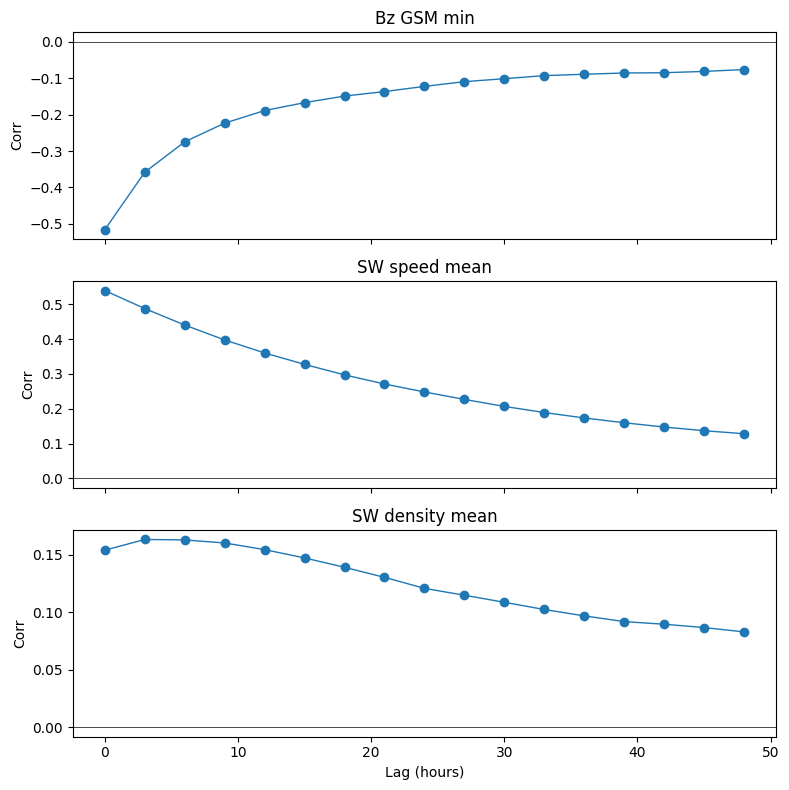

In [53]:
# 3) Lagged correlations (driver(t) vs Kp(t+lag))
def lagged_corr(driver_col, max_lag_hours= 48):
  lags = np.arange(0, max_lag_hours + 3, 3)  # 0,3,...,24
  corrs = []
  for lag in lags:
      shifted_kp = df["kp"].shift(-lag // 3)
      corr_val = df[driver_col].corr(shifted_kp)
      corrs.append(corr_val)
  return lags, corrs

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
drivers = [
  ("bz_gsm_3h_min", "Bz GSM min"),
  ("sw_speed_3h_mean", "SW speed mean"),
  ("sw_density_3h_mean", "SW density mean"),
]

for ax, (col, label) in zip(axes, drivers):
  lags, corrs = lagged_corr(col)
  ax.plot(lags, corrs, marker="o", linewidth=1)
  ax.axhline(0, color="black", linewidth=0.5)
  ax.set_ylabel("Corr")
  ax.set_title(label)

axes[-1].set_xlabel("Lag (hours)")
plt.tight_layout()
plt.show()


## How to read this figure

Each curve shows the **Pearson correlation between a driver at time *t* and Kp at time *t + lag***, with lag extending up to ~48 hours. The curves describe **direction, strength, and persistence** of linear association, not causality.

---

## 1️ **Bz GSM min → Kp**

### Observed pattern

* Strong negative correlation at **lag 0** (≈ −0.5).
* Rapid decay in magnitude over the first ~6–12 hours.
* A shallow, long negative tail persisting out to ~48 hours.

### Interpretation

* Southward IMF has an **immediate and dominant coupling** with geomagnetic activity.
* The fast initial decay indicates a **short magnetospheric memory** for direct Bz forcing.
* The persistent weak tail at long lags reflects **storm persistence and recovery**, not delayed forcing.

### Takeaway

> **Bz is a fast-acting trigger variable with limited standalone memory beyond ~12 hours.**

---

## 2️ **Solar wind speed → Kp**

### Observed pattern

* Moderate positive correlation at lag 0 (≈ 0.5).
* Smooth, monotonic decay with lag.
* Correlation remains positive even at ~48 hours.

### Interpretation

* Solar wind speed acts as a **slowly varying background driver**.
* High-speed streams influence geomagnetic activity over **multi-day timescales**.
* The absence of a sharp peak indicates **amplification and conditioning**, not impulsive triggering.

### Takeaway

> **Solar wind speed provides long-memory context rather than precise timing information.**

---

## 3️⃣ **Solar wind density → Kp**

### Observed pattern

* Weak positive correlation throughout (≈ 0.1–0.17).
* Broad, flat maximum at short lags.
* Gradual decay toward longer lags.

### Interpretation

* Density has a **secondary, diffuse influence**, likely through dynamic pressure effects.
* No distinct lag structure suggests its role is **contextual and conditional**.
* Linear instantaneous coupling is weak.

### Takeaway

> **Density is a low-signal, supporting variable rather than a primary driver.**

---

## Cross-driver synthesis

* No driver shows a **sharp optimal lag**, indicating that geomagnetic activity is not governed by a single delayed impulse.
* Drivers exhibit **distinct memory scales**:

  * **Bz**: strong, short-memory
  * **Speed**: moderate, long-memory
  * **Density**: weak, diffuse
* This confirms a **multiscale, multivariate system** where persistence and joint conditions matter more than single-step values.



# **Part 4 — Horizon & Predictability (Definitive EDA Target)**

### Purpose

Quantify how **predictive information decays with forecast horizon**, and determine whether this decay is due to **information limits** or **model linearity limits**.

---

## **4.1 Target Definition (Frozen)**
 I define horizon‑specific binary targets directly from Kp by taking the max Kp in the next 1, 2, 4, or 8 three‑hour bins (3h–24h). The features and rows stay fixed; only the target window shifts, so horizon effects are
  isolated.

In [61]:
HORIZONS = {"3h": 1, "6h": 2, "12h": 4, "24h": 8, "48h": 16}

for name, h in HORIZONS.items():
  df[f"target_{name}"] = (
      df["kp"]
      .rolling(h, min_periods=1)
      .max()
      .shift(-h)
      >= 5
  ).astype(int)

# Drop tail rows with undefined future window (recommended)
max_h = max(HORIZONS.values())
df_targets = df.iloc[:-max_h].copy()


 # 4.2 Event rate vs horizon

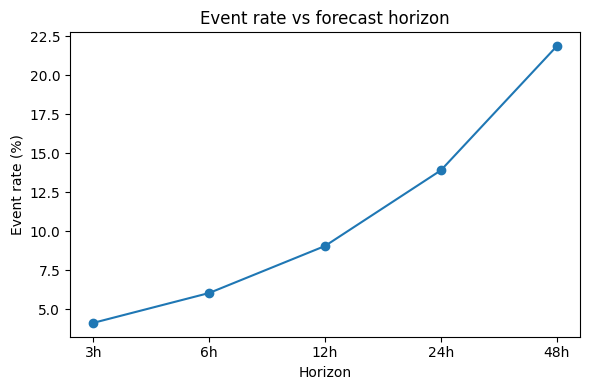

{'3h': np.float64(0.0414017831051613), '6h': np.float64(0.060545076611769374), '12h': np.float64(0.09068253119331308), '24h': np.float64(0.13919137228523065), '48h': np.float64(0.21873087462576296)}


In [62]:
event_rates = {name: df_targets[f"target_{name}"].mean() for name in HORIZONS}

plt.figure(figsize=(6, 4))
plt.plot(list(HORIZONS.keys()), [event_rates[k] * 100 for k in HORIZONS], marker="o")
plt.title("Event rate vs forecast horizon")
plt.xlabel("Horizon")
plt.ylabel("Event rate (%)")
plt.tight_layout()
plt.show()

print(event_rates)

The event rate rises with horizon, from about 4% at 3h to ~14% at 24h, indicating increasing class imbalance as the window grows. This sets an upper bound on how easy longer‑horizon prediction can be.


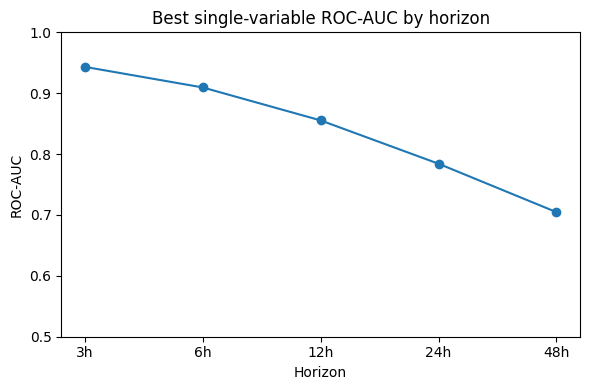

{'3h': 0.9432854388913294, '6h': 0.9094543119900227, '12h': 0.855334278615671, '24h': 0.7841569137529965, '48h': 0.7046593961490296}


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


# ---- 4.3 Single-variable information content ----
single_vars = {
  "bz_gsm_3h_min": -1,   # negate so larger = more storm-like
  "sw_speed_3h_mean": 1,
  "sw_density_3h_mean": 1,
  "kp": 1,               # persistence reference
}

best_auc_by_horizon = {}

for name, h in HORIZONS.items():
  target = df_targets[f"target_{name}"]
  best_auc = -np.inf
  for col, sign in single_vars.items():
      valid = df_targets[[col, f"target_{name}"]].dropna()
      if valid.empty:
          continue
      auc = roc_auc_score(valid[f"target_{name}"], sign * valid[col])
      best_auc = max(best_auc, auc)
  best_auc_by_horizon[name] = best_auc

plt.figure(figsize=(6, 4))
plt.plot(list(HORIZONS.keys()), [best_auc_by_horizon[k] for k in HORIZONS], marker="o")
plt.title("Best single-variable ROC-AUC by horizon")
plt.xlabel("Horizon")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

print(best_auc_by_horizon)


 The best single raw driver achieves high AUC at short horizons (≈0.94 at 3h) but decays steadily toward 24h (≈0.78), showing that raw physical signal weakens with forecast distance.


Despite using only a single raw driver and simple models, discrimination performance remains well above chance at 24 h. This indicates that near-Earth solar-wind conditions encode persistent information about geomagnetic activity on day-ahead timescales, primarily through regime persistence rather than instantaneous triggering.


In [64]:


# ---- 4.4 Linear vs Non-linear separability probe ----
features = [
  "bz_gsm_3h_min",
  "sw_speed_3h_mean",
  "sw_density_3h_mean",
  "sw_temperature_3h_mean",
  "kp",
]

# Walk-forward splits (adjust if you prefer)
splits = {
  "train": ("2010-01-01", "2018-12-31"),
  "val": ("2019-01-01", "2020-12-31"),
  "test": ("2021-01-01", "2024-12-31"),
}

def time_filter(df_in, start, end):
  mask = (df_in["timestamp_utc"] >= start) & (df_in["timestamp_utc"] <= end)
  return df_in.loc[mask]

models = {
  "logreg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
  "tree": DecisionTreeClassifier(max_depth=3, random_state=0),
}

results = []

for horizon in HORIZONS:
  target_col = f"target_{horizon}"
  data = df_targets[["timestamp_utc"] + features + [target_col]].dropna()

  train = time_filter(data, *splits["train"])
  val = time_filter(data, *splits["val"])
  test = time_filter(data, *splits["test"])

  X_train, y_train = train[features], train[target_col]
  X_val, y_val = val[features], val[target_col]
  X_test, y_test = test[features], test[target_col]

  for model_name, model in models.items():
      model.fit(X_train, y_train)
      val_pred = model.predict_proba(X_val)[:, 1]
      test_pred = model.predict_proba(X_test)[:, 1]

      results.append({
          "horizon": horizon,
          "model": model_name,
          "val_auc": roc_auc_score(y_val, val_pred),
          "test_auc": roc_auc_score(y_test, test_pred),
      })

results_df = pd.DataFrame(results)
display(results_df)

,horizon,model,val_auc,test_auc
0,3h,logreg,0.983527,0.956370
1,3h,tree,0.902996,0.924985
2,6h,logreg,0.952893,0.908288
3,6h,tree,0.871830,0.868716
4,12h,logreg,0.894380,0.832747
5,12h,tree,0.830282,0.802857
6,24h,logreg,0.820897,0.738739
7,24h,tree,0.782533,0.725656
8,48h,logreg,0.655648,0.657465
9,48h,tree,0.657488,0.646274


The fact that a depth-3 decision tree does not improve over logistic regression across any horizon indicates that non-linear threshold effects are weak in the space of raw drivers. This suggests that geomagnetic predictability at these horizons is governed by smooth, monotonic responses and persistence, and that model expressiveness is not the limiting factor prior to explicit temporal aggregation.

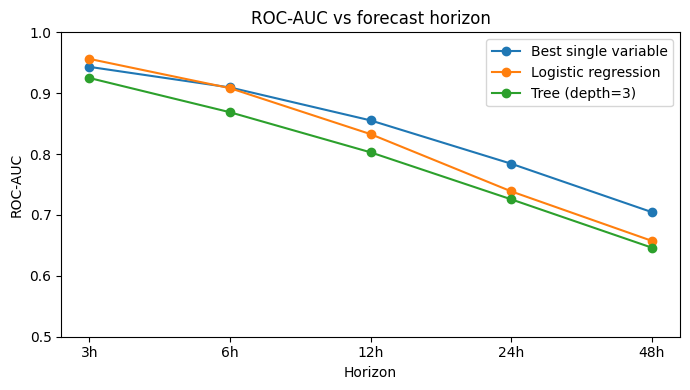

In [65]:
# 4.5 Horizon decay comparison (main plot)

# Pull model AUCs by horizon
logreg_auc = results_df[results_df["model"] == "logreg"].set_index("horizon")["test_auc"]
tree_auc = results_df[results_df["model"] == "tree"].set_index("horizon")["test_auc"]

horizons = list(HORIZONS.keys())
x = np.arange(len(horizons))

plt.figure(figsize=(7, 4))
plt.plot(horizons, [best_auc_by_horizon[h] for h in horizons], marker="o", label="Best single variable")
plt.plot(horizons, [logreg_auc[h] for h in horizons], marker="o", label="Logistic regression")
plt.plot(horizons, [tree_auc[h] for h in horizons], marker="o", label="Tree (depth=3)")

plt.title("ROC-AUC vs forecast horizon")
plt.xlabel("Horizon")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.show()


ROC-AUC decreases smoothly with forecast horizon for all probes, indicating gradual information loss rather than a sharp predictability limit. A single raw driver already provides substantial discrimination skill, particularly at short horizons, while multivariate logistic regression yields modest but consistent gains. The absence of improvement from a shallow decision tree suggests that non-linear threshold effects are weak in the space of raw contemporaneous drivers. Overall, this comparison indicates that predictability is primarily information-limited at longer horizons and that further gains must arise from temporal aggregation rather than increased model complexity.

## Conclusion (EDA synthesis)

- The 3-hour Kp–OMNI grid is regular over the overlap period, with missingness concentrated in early OMNI years; recent decades are near-complete.
- Kp is strongly right-skewed and bursty, with storm counts clustering around active solar-cycle periods and a clear semiannual pattern.
- Driver distributions are heavy-tailed and non-Gaussian; extreme Kp coincides with persistent southward Bz and elevated solar-wind speed.
- Instantaneous correlations are moderate and collinear, while lag analysis shows short-memory Bz vs long-memory speed, supporting multiscale coupling.
- Overall, the dataset is physically consistent and suitable for horizon-based analysis, with explicit handling of early-period missing data.
